# Day 08. Exercise 03
# Overfitting

## 0. Imports

In [168]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn import linear_model
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import joblib


## 1. Preprocessing

1. Read the file `dayofweek.csv` to a dataframe.
2. Using `train_test_split` with parameters `test_size=0.2`, `random_state=21` get `X_train`, `y_train`, `X_test`, `y_test`.
3. Using, for example, `value_counts()` to check if the distribution of classes is similar in train and test.
4. Use the additional parameter `stratify=` and check the distribution again, now it should be more or less similar in both datasets.

#### 1) Reading the file

In [134]:
df = pd.read_csv("../ex02/dayofweek.csv")
display(df)

,numTrials,hour,dayofweek,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,...,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,-0.788667,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.756764,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.724861,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.692958,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.661055,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,-0.533442,0.945382,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1682,-0.629151,0.945382,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1683,-0.597248,0.945382,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1684,-0.565345,0.945382,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


#### 2) Selecting

First, we need to divide our data into features (X) and labels (y). The dataframe gets divided into X_train,X_test , y_train and y_test. X_train and y_train sets are used for training and fitting the model. The X_test and y_test sets are used for testing the model if it’s predicting the right outputs/labels. 
__by default, 25% of our data is test set and 75% data goes into training tests__

In [135]:
X = df.drop(["dayofweek"], axis=1)
Y = df["dayofweek"]

In [136]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=21, test_size=0.2)

#### 3) Distribution check

In [137]:
display(Y_test.value_counts())

dayofweek
3    83
6    69
5    55
1    52
0    31
4    24
2    24
Name: count, dtype: int64

In [138]:
Y_train.value_counts()

dayofweek
3    313
6    287
1    222
5    216
2    125
0    105
4     80
Name: count, dtype: int64

Проверим графически

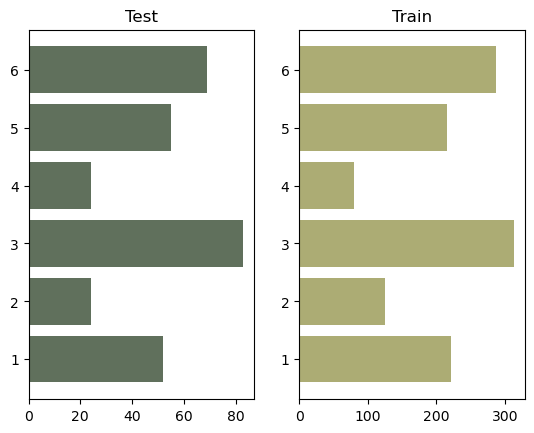

In [139]:
fig, ax = plt.subplots(nrows=1, ncols=2)
# Y_test
y = [Y_test.value_counts()[i] for i in range(1, 7)]
ax[0].barh(range(1, 7), y, color="#60705c")
ax[0].set_title("Test")
# Y_train
y = [Y_train.value_counts()[i] for i in range(1, 7)]
ax[1].barh(range(1, 7), y, color="#acac74")
ax[1].set_title("Train")

plt.show()

Видно, что учебная и тестовая выборки имеют одинаковое распределение классов

#### 4) Stratify

Теперь проверим через stratify:

In [140]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=21, test_size=0.2, stratify=Y)

In [141]:
display(Y_test.value_counts())
display(Y_train.value_counts())

dayofweek
3    80
6    71
1    55
5    54
2    30
0    27
4    21
Name: count, dtype: int64

dayofweek
3    316
6    285
1    219
5    217
2    119
0    109
4     83
Name: count, dtype: int64

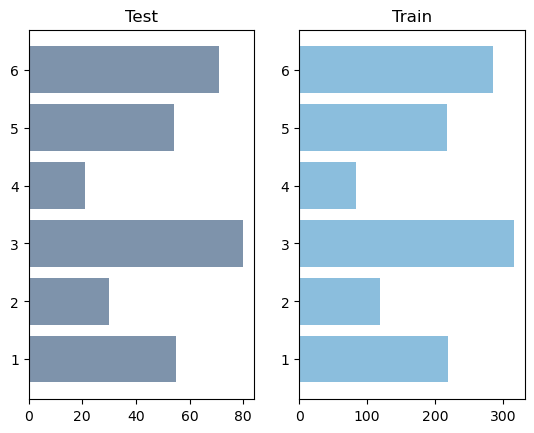

In [142]:
fig, ax = plt.subplots(nrows=1, ncols=2)
# Y_test
y = [Y_test.value_counts()[i] for i in range(1, 7)]
ax[0].barh(range(1, 7), y, color="#7e93ab")
ax[0].set_title("Test")
# Y_train
y = [Y_train.value_counts()[i] for i in range(1, 7)]
ax[1].barh(range(1, 7), y, color="#8bbedd")
ax[1].set_title("Train")

plt.show()

Видно, что в обоих случаях разделение одинаковое

## 2. Baseline models

1. Train exactly the same baseline models from the previous exercise and calculate the accuracies using the test dataset with stratification.
2. Did all the models show the similar values of the metric? Which one has the largest difference comparing the current exercise and the previous? Put the answer to the markdown cell in the end of the section.

### a. Logreg

In [143]:
reg = linear_model.LogisticRegression(random_state=21, fit_intercept=False)
reg.fit(X_train, Y_train)
accuracy_score(Y_test, reg.predict(X_test))

0.6331360946745562

В прошлом задании точность была 0.640

### b. SVM

In [144]:
svc = SVC(kernel="linear", probability=True, random_state=21)
svc.fit(X_train, Y_train)
accuracy_score(Y_test, svc.predict(X_test))

0.7159763313609467

Против 0.702846975088968 в прошлом задании

### c. Decision tree

In [145]:
clf = DecisionTreeClassifier(max_depth=4, random_state=21)
clf.fit(X_train, Y_train)
accuracy_score(Y_test, clf.predict(X_test))

0.5295857988165681

Против 0.5516014234875445 в предыдущем задании

### d. Random forest

In [146]:
classifier = RandomForestClassifier(n_estimators=100, random_state=21, max_depth=25)
classifier.fit(X_train, Y_train)
accuracy_score(Y_test, classifier.predict(X_test))

0.9289940828402367

Против 1.0 точности в предыдущем задании

### Answer
Which one has the largest difference comparing the current exercise and the previous? - __Random Forest Model__

## 3. Crossvalidation

We could play with parameters of the model trying to achive a better accuracy on the test dataset, but it is a bad practice. It leads us again to overfitting. Test dataset is only for checking quality of a final model.

But there is another way of solving the problem – crossvalidation. It does not use test dataset, but creates one more split of train dataset. Again, there are different ways of doing it, but the common thing is that there is a validation dataset that is used for hyperparameters optimization.

1. Using `cross_val_score` with `cv=10` calculate the mean accuracy and standard deviation for every model that you used before (logreg with `solver='liblinear'`, SVC, decision tree, random forest).


<br>Гиперпараметры — это параметры, которые настраиваются до начала процесса обучения и определяют как саму структуру модели, так и способ её обучения. Их правильный выбор может значительно повлиять на результаты обучения, тогда как неправильно подобранные значения гиперпараметров могут привести к нежелательным и недооцененным моделям.</br>

_Примеры типичных гиперпараметров для разных алгоритмов:_
* Random_forest: max_depth, n_estimators
* SVM: kernel

*[Гиперпараметрический поиск и оптимизация моделей](https://habr.com/ru/companies/otus/articles/754402/)


### a. Logreg

In [149]:
reg = linear_model.LogisticRegression(random_state=21, fit_intercept=False, solver='liblinear')
cv_scores = cross_val_score(reg, X_train, Y_train, cv=10, scoring='accuracy')   # разделяет X, Y на 10 частей, на 9/10 частей обучает, на 1/10 тестит

print("Cross-Validation Scores:", cv_scores)
print("Average Score:", cv_scores.mean())
print("σ:", cv_scores.std())

Cross-Validation Scores: [0.56296296 0.61481481 0.59259259 0.60740741 0.55555556 0.57777778
 0.61481481 0.53333333 0.58208955 0.57462687]
Average Score: 0.5815975677169707
σ: 0.025322132907253592


Как видно, по набору точностей и стандартному отклонению, точность несильно скачет, а значит, модель постоянна

### b. SVM

In [150]:
cv_scores = cross_val_score(svc, X_train, Y_train, cv=10, scoring="accuracy")
print(cv_scores)
print(cv_scores.mean())
print(cv_scores.std())

[0.65925926 0.75555556 0.62222222 0.65185185 0.65185185 0.64444444
 0.72592593 0.62222222 0.61940299 0.63432836]
0.6587064676616916
0.043585708770590564


### c. Decision tree

In [151]:
cv_scores = cross_val_score(clf, X_train, Y_train, cv=10, scoring="accuracy")
print(cv_scores)
print(cv_scores.mean())
print(cv_scores.std())

[0.48148148 0.52592593 0.47407407 0.52592593 0.57037037 0.51111111
 0.5037037  0.48888889 0.54477612 0.46268657]
0.5088944168048645
0.031903139495514356


### d. Random forest

In [152]:
cv_scores = cross_val_score(classifier, X_train, Y_train, cv=10, scoring="accuracy")
print(cv_scores)
print(cv_scores.mean())
print(cv_scores.std())

[0.9037037  0.96296296 0.8962963  0.94074074 0.91851852 0.8962963
 0.92592593 0.8962963  0.93283582 0.90298507]
0.9176561636263129
0.02159583796321821


Как видно, дерево решений хуже всех прошла кросс-валидацию

## 4. Optimization

1. Choose the best model and play a little bit with the parameters on cross-validation, find a good enough parameter or a combination of the parameters.
2. Calculate the accuracy for the final model on the test dataset.
3. Draw a plot that displays the top-10 most  important features for that model.
4. Save the model using `joblib`.
5. Load the model, make predictions for the test dataset and calculate the accuracy.

Возьмем Random Forest Model. Из предыдущего задания видно, что лучшими параметрами были max_depth=25, n_estimators=100. Проверим это через кросс-валидацию

#### 1) Choose the best parameters

In [160]:
best_std = 10
best_d = 0
best_e = 0
for d in range(20, 41, 5):
    for e in range(70, 151, 10):
        forest = RandomForestClassifier(max_depth=d, random_state=21, n_estimators=e)
        cv_scores = cross_val_score(forest, X_train, Y_train, cv=10, scoring="accuracy")
        if cv_scores.std() < best_std:
            best_std = cv_scores.std()
            best_d = d
            best_e = e

print(f"best depth = {best_d} and best number of estimators = {best_e} (σ={best_std})")
del best_e, best_d, best_std

best depth = 30 and best number of estimators = 110 (σ=0.01209421607123627)


Можно увеличить max_depth до 30

#### 2) Accuracy

In [161]:
best_forest = RandomForestClassifier(max_depth=30, random_state=21, n_estimators=110)
best_forest.fit(X_train, Y_train)
accuracy_score(Y_test, best_forest.predict(X_test))


0.9378698224852071

#### 3) Plotting

In [166]:
def barh(coef: list, features, top: int):
    """Принимает coef как одномерный масив
    features - dataframe
    """

    sorted_indexes = coef.argsort()[::-1][:top]
    
    fig, ax = plt.subplots(figsize=(15, 8))
    plt.barh(features[sorted_indexes], coef[sorted_indexes], color="#c2ff80")
    plt.title("The most important features")
    ax.invert_yaxis()
    plt.show()

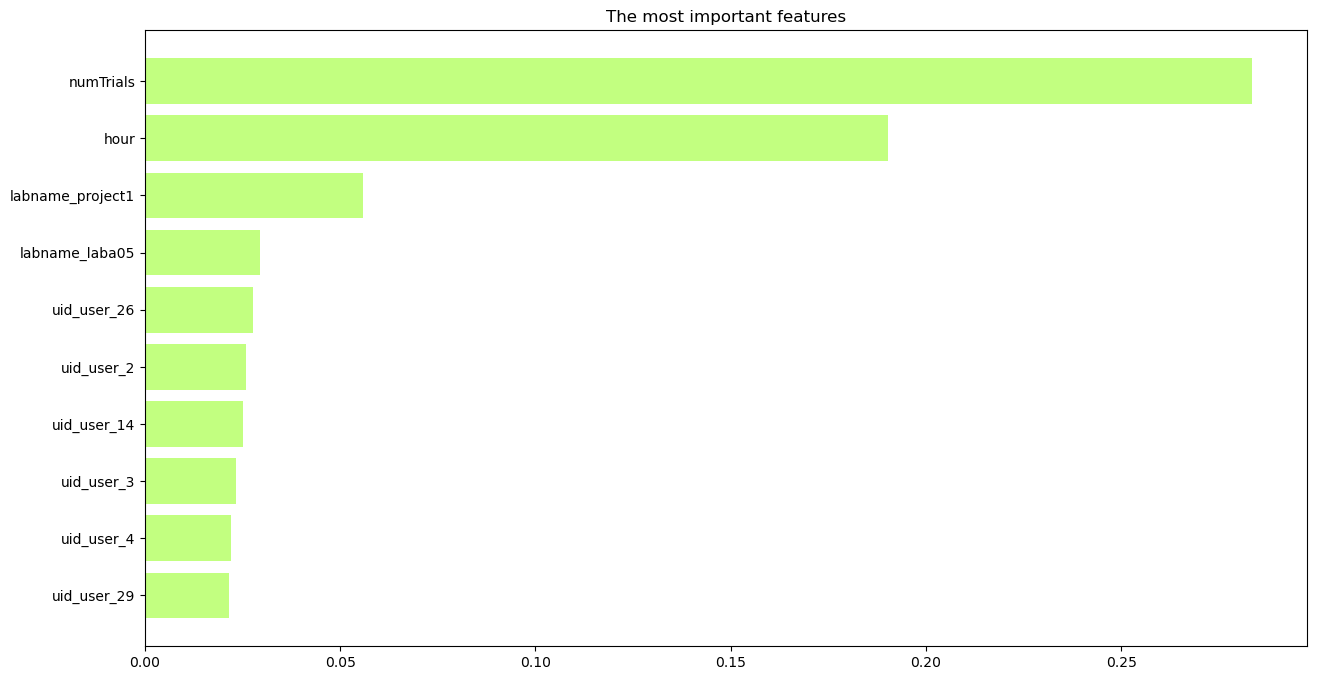

In [167]:
barh(coef=best_forest.feature_importances_, features=df.drop(["dayofweek"], axis=1).columns, top=10)

#### 4) Save the model

<br>__Machine Learning models__ require large datasets to get high accuracy, so in order to train a machine learning model with a large-size dataset, we also need a reasonable amount of time. So we use the joblib library to get rid of training the model again and again, instead, what we do is just train the model once and then save it using the joblib library, and then we use the same model.</br>
__Joblib__ is a Python library for running computationally intensive tasks in parallel. It provides a set of functions for performing operations in parallel on large data sets and for caching the results of computationally expensive functions. Joblib is especially useful for machine learning models because it allows you to save the state of your computation and resume your work later or on a different machine.

*[How to Save and Load Machine Learning Models in Python Using Joblib Library?](https://www.analyticsvidhya.com/blog/2023/02/how-to-save-and-load-machine-learning-models-in-python-using-joblib-library/)

In [169]:
joblib.dump(best_forest, "best_model.joblib")

['best_model.joblib']

#### 5) Loading the model, making predictions, calculating accuracy

In [170]:
model = joblib.load("best_model.joblib")
predictions = model.predict(X_test)

In [171]:
accuracy_score(Y_test, predictions)

0.9378698224852071